# Code for Figures, LN DMS Data

- Figure 5
- Figure S5

## Load Libraries

In [2]:
options(warn = -1)

suppressPackageStartupMessages({
  library(plyranges)
  library(tidyverse)
  library(rasilabRtemplates)
  library(ggpubr)
  library(RColorBrewer)
  library(ggseqlogo)
})

In [3]:
insert_annotations <- read_csv("../annotations/insert_annotations.csv", show_col_types = F) %>%
    print()

barcode_annotations <- read_csv("../data/filtered_barcodes/filtered_barcodes_linkage.csv", show_col_types = F) %>%
    print()

# A tibble: 1,387 × 8
   wt_codon codon_position mut_codon insert_seq     wt_aa mut_aa inser…¹ row_num
   <chr>             <dbl> <chr>     <chr>          <chr> <chr>  <chr>     <dbl>
 1 ATG                   1 TTT       TTTGACGCTCAGA… M     F      GTTGGC…       1
 2 ATG                   1 TTC       TTCGACGCTCAGA… M     F      GTTGGC…       2
 3 ATG                   1 TTA       TTAGACGCTCAGA… M     L      GTTGGC…       3
 4 ATG                   1 TTG       TTGGACGCTCAGA… M     M      GTTGGC…       4
 5 ATG                   1 TCT       TCTGACGCTCAGA… M     S      GTTGGC…       5
 6 ATG                   1 TCC       TCCGACGCTCAGA… M     S      GTTGGC…       6
 7 ATG                   1 TCA       TCAGACGCTCAGA… M     S      GTTGGC…       7
 8 ATG                   1 TCG       TCGGACGCTCAGA… M     S      GTTGGC…       8
 9 ATG                   1 TAT       TATGACGCTCAGA… M     Y      GTTGGC…       9
10 ATG                   1 TAC       TACGACGCTCAGA… M     Y      GTTGGC…      10
# … wi

In [4]:
target_data <- list.files("../data/summary_stats/", full.names = T, pattern = ".csv") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(insert_annotations, by = c("insert_num"="row_num")) %>%
    print()

# A tibble: 7,925 × 97
   barcode       read_…¹ num_0_a num_0_g num_0_t num_0_c num_0_n num_1_a num_1_g
   <chr>           <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 CCGAAGCCGCAA…    1772    1771    1771       1    1427    1772       0       0
 2 AGCGACAACAGA…     746     746     745       0     429     746       0       1
 3 AAGGCGCCCGGC…     785     784     784       1     678     785       0       0
 4 CAAGAAGAAACC…    2337    2334    2335       0    2144    2337       3       1
 5 GAGCACGAAGGG…     974     974     974       0     584     974       0       0
 6 CGGCAACAGGCC…    1632    1629    1630       0    1070    1632       3       1
 7 GGGCGGGAAGGC…    1449    1447    1448       0    1315    1449       2       1
 8 ACAACCACGAGG…     389     389     389       0     388     389       0       0
 9 CCAGAGAAAACC…     718     716     716       0     249     718       2       2
10 AGCGCCAAACGG…    2079    2079    2077       0    1527    2079       0       2
# … w

## Generate Data Tables

### Normalized Editing Efficiency for Amino Acid Combinations

In [5]:
aa_reorder_list <- c("M", "L", "I", "V", "A", "T", "S", "Q", "N", "D", "E", "R", "K", "H", "W", "Y", "F", "P", "G", "C", "*")

calc_fraction_bootstrap <- function(data, indices) {
  d <- data[indices,]
  1-(sum(d$num_0_c)/sum(d$read_counts))
}
set.seed <- 1234

wt_aa_order<- target_data %>% select(codon_position,wt_aa) %>% distinct() %>% arrange(codon_position)
x_order<-wt_aa_order$wt_aa
x_breaks <- wt_aa_order$codon_position

wt_data <- target_data %>%
    mutate(is_wt= mut_aa==wt_aa)%>%
    filter(is_wt)%>%
    select(codon_position,mut_aa)%>%
    print()

lfc_data <- target_data  %>%
  group_by(codon_position,mut_aa,wt_aa)%>%
  filter(sum(read_counts)>10,n()>3)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

wt_editing<-lfc_data%>%
    filter(wt_aa==mut_aa) %>% 
    pull(fraction_edited) %>%
    median()%>%
    print()

full_grid <- expand_grid(
  codon_position = unique(lfc_data$codon_position),
  mut_aa = aa_reorder_list 
)

lfc_normalized<-lfc_data %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    right_join(full_grid, by = c("codon_position", "mut_aa"))

write_tsv(lfc_normalized,"../tables/lfc_normalized.tsv")

# A tibble: 524 × 2
   codon_position mut_aa
            <dbl> <chr> 
 1              7 R     
 2             11 R     
 3              8 R     
 4              8 R     
 5              7 R     
 6              5 T     
 7              6 R     
 8             19 K     
 9              8 R     
10             10 R     
# … with 514 more rows
# A tibble: 420 × 5
   codon_position wt_aa mut_aa fraction_edited fraction_sd
            <dbl> <chr> <chr>            <dbl>       <dbl>
 1              9 E     R               0.223       0.0343
 2              8 R     A               0.140       0.0180
 3              6 R     S               0.118       0.0185
 4              6 R     W               0.0875      0.0229
 5             10 R     K               0.191       0.0462
 6             22 N     K               0.171       0.113 
 7              1 M     T               0.159       0.0527
 8             18 W     *               0.192       0.0668
 9             14 K     F               0.218  

## Figure 6

### 6B

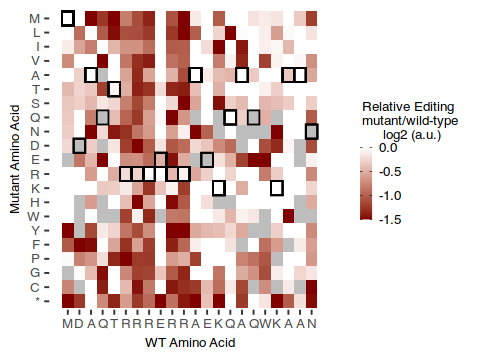

In [104]:
lfc_normalized%>%
    ggplot(aes(x=codon_position,y=mut_aa,fill=lfc))+
        geom_tile()+
        geom_tile(data = wt_data, 
            aes(x = codon_position, y = mut_aa), 
            color = "black", fill = NA, linewidth = 0.5) +  # draw red outline on wt aa
    #     scale_fill_gradient2(
    #         name = "LFC",
    #         low = "blue",       
    #         # mid = "white",      
    #         high = "red",
    #         oob = scales::squish,      
    #         limits = c(-1, 1),      
    #         guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"),
    #         na.value = "grey"
    # )+
        scale_fill_gradient(
            name="Relative Editing \n mutant/wild-type \n log2 (a.u.)",
            low = "#800000", high = "#FFFFFF",
            oob = scales::squish,
            limits = c(-1.5, 0.0),
            guide = guide_colorbar(barwidth = 0.5, barheight = 3, ticks.colour = "black"), na.value = "grey")+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        scale_x_continuous(breaks=x_breaks,labels=x_order)+
        theme(
            axis.title.x = element_text(margin = margin(t = 4)),
            axis.line = element_blank(),
            axis.title = element_text(size = 8),
            axis.text = element_text(size = 8),
            legend.title = element_text(size = 8),
            legend.title.align = 0.5,
            legend.text = element_text(size = 8),
            )+
        labs(x = "WT Amino Acid", y = "Mutant Amino Acid",
         )
ggsave("../figures/lfc_heatmap_filtered.pdf",height = 3.5,width = 4.75)

### 6B Summary Strips

In [14]:
# wt_data <- target_data %>%
#     mutate(is_wt= mut_aa==wt_aa)%>%
#     filter(is_wt)%>%
#     select(codon_position,mut_aa)%>%
#     print()

position_lfc_data <- target_data  %>%
  group_by(codon_position)%>%
  filter(sum(read_counts)>10,n()>3,wt_aa!=mut_aa)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

wt_editing<-lfc_data%>%
    filter(wt_aa==mut_aa) %>% 
    pull(fraction_edited) %>%
    median()%>%
    print()

position_lfc_normalized<-position_lfc_data %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    print()

# write_tsv(lfc_normalized,"../tables/position_lfc_normalized.tsv")

aa_lfc_data <- target_data  %>%
  group_by(mut_aa)%>%
  filter(sum(read_counts)>10,n()>3,wt_aa!=mut_aa)%>%
  nest()%>%
  mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
  select(-data)%>%
  mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
  mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
  select(-fraction_boot) %>%
  ungroup() %>%
  print()

aa_lfc_normalized<-aa_lfc_data %>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    print()

# A tibble: 22 × 3
   codon_position fraction_edited fraction_sd
            <dbl>           <dbl>       <dbl>
 1              9          0.227      0.0124 
 2              8          0.101      0.00383
 3              6          0.118      0.00593
 4             10          0.109      0.00615
 5             22          0.155      0.0134 
 6              1          0.182      0.0131 
 7             18          0.149      0.0124 
 8             14          0.160      0.0137 
 9             16          0.161      0.0124 
10              7          0.0985     0.00494
# … with 12 more rows
[1] 0.2107429
# A tibble: 22 × 4
   codon_position fraction_edited fraction_sd    lfc
            <dbl>           <dbl>       <dbl>  <dbl>
 1              9          0.227      0.0124   0.106
 2              8          0.101      0.00383 -1.06 
 3              6          0.118      0.00593 -0.840
 4             10          0.109      0.00615 -0.953
 5             22          0.155      0.0134  -0.444
 6 

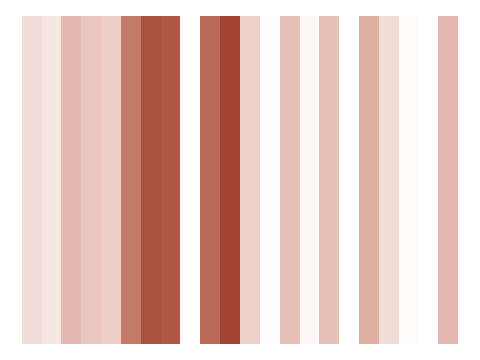

In [18]:
position_lfc_normalized%>%
    ggplot(aes(x=codon_position,y=1,fill=lfc))+
        geom_tile()+
        scale_fill_gradient(
            name="Relative Editing \n mutant/wild-type \n log2 (a.u.)",
            low = "#800000", high = "#FFFFFF",
            oob = scales::squish,
            limits = c(-1.5, 0.0),
            guide = FALSE)+
        scale_x_continuous(breaks=x_breaks,labels=x_order)+
        theme_void()

ggsave("../figures/lfc_position.pdf",height = 0.3,width = 4.75)

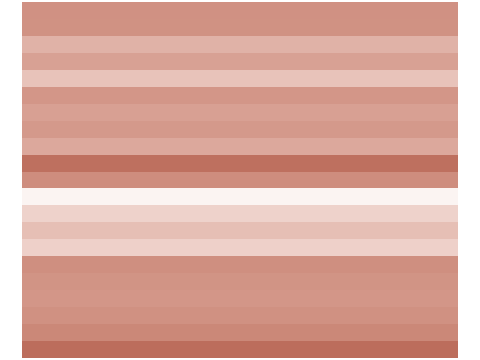

In [20]:
aa_lfc_normalized%>%
    ggplot(aes(x=1,y=mut_aa,fill=lfc))+
        geom_tile()+
        scale_fill_gradient(
            name="Relative Editing \n mutant/wild-type \n log2 (a.u.)",
            low = "#800000", high = "#FFFFFF",
            oob = scales::squish,
            limits = c(-1.5, 0.0),
            guide = FALSE)+
        scale_y_discrete(limits = rev(aa_reorder_list))+
        theme_void()

ggsave("../figures/lfc_aa.pdf",height = 4.75,width = 0.3)

### 6C: Output Per Residue Average for Structural Figure

In [ ]:
lfc_normalized %>%
filter(wt_aa!=mut_aa)%>%
group_by(codon_position)%>%
summarize(mean_lfc=mean(lfc))%>%
filter(codon_position>1)%>%
write_csv("../tables/dms_data.csv")

## Supplementary Figure 5

### S5B

In [22]:
grouped_data<- target_data %>%
    group_by(wt_aa,mut_aa,codon_position)%>%
    filter(read_counts>20,n()>6)%>%
    mutate(group=sample(rep(c("a", "b"), length.out = n())))%>%
    group_by(group,wt_aa,mut_aa,codon_position)%>%
    # nest()%>%
    # mutate(fraction_boot = map(data, function(df) boot::boot(data=df, statistic=calc_fraction_bootstrap, R=100)$t)) %>%
    # select(-data)%>%
    # mutate(fraction_edited = map_dbl(fraction_boot, mean)) %>%
    # mutate(fraction_sd = map_dbl(fraction_boot, sd)) %>%
    # select(-fraction_boot) %>%
    # ungroup() %>%
    # select(-fraction_sd)%>%
    summarize(fraction_edited=1-(sum(num_0_c)/sum(read_counts)))%>%
    mutate(lfc=log2(fraction_edited)-log2(wt_editing))%>%
    select(-fraction_edited)%>%
    pivot_wider(names_from = group,values_from = lfc)%>%
    filter(!is.na(a),!is.na(b))%>%
    print()

grouped_data

`summarise()` has grouped output by 'group', 'wt_aa', 'mut_aa'. You can
override using the `.groups` argument.


# A tibble: 337 × 5
# Groups:   wt_aa, mut_aa [158]
   wt_aa mut_aa codon_position       a      b
   <chr> <chr>           <dbl>   <dbl>  <dbl>
 1 A     *                   3 -0.766   0.642
 2 A     *                  12 -1.89   -1.83 
 3 A     *                  16 -1.94   -0.447
 4 A     *                  20 -0.552  -4.06 
 5 A     *                  21  0.0772 -0.943
 6 A     A                   3 -0.316   0.370
 7 A     A                  12  0.519   0.266
 8 A     A                  16 -4.48    0.614
 9 A     A                  20 -0.939   0.361
10 A     A                  21  0.424   0.591
# … with 327 more rows


wt_aa,mut_aa,codon_position,a,b
<chr>,<chr>,<dbl>,<dbl>,<dbl>
A,*,3,-0.7659214,0.6419411
A,*,12,-1.8908238,-1.8303383
A,*,16,-1.9423543,-0.4468452
A,*,20,-0.5517137,-4.0573369
A,*,21,0.0771869,-0.9429101
⋮,⋮,⋮,⋮,⋮
W,P,18,-1.04817692,-1.0694230
W,R,18,-0.44645498,-1.9703103
W,S,18,0.02805945,-2.0277374


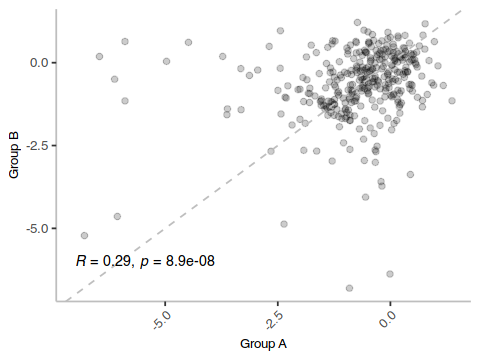

In [29]:
grouped_data %>%
    ggplot(aes(x=a,y=b))+
    geom_point(alpha=0.2)+
    theme_classic()+
    geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray") +
    stat_cor(method = "spearman",label.x=-7,label.y=-6,size=3)+
        labs(x = "Group A", y = "Group B"
         )+
    # scale_x_continuous(limits=c(0,0.5))+
    # scale_y_continuous(limits=c(0,0.5)) +
    theme(
      axis.title = element_text(size = 8),
      axis.text = element_text(size = 8),
      legend.title = element_text(size = 8),
      legend.text = element_text(size = 8),
      strip.text.x = element_text(size=8),
      strip.background = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.line = element_line(color = "grey")
    )

ggsave("../figures/random_correlations.pdf",height = 2,width = 2)